In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:


torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:

###############################################################
# Simulation parameters
###############################################################

dt         = 0.01
Time_steps = 500
iters      = 1000


In [5]:

###############################################################
# Enterprise network size
###############################################################

TOTAL_HOSTS = 1000.0


In [6]:


###############################################################
# Fixed model parameters
###############################################################

eta = 0.20          # quarantine restoration rate


In [7]:


###############################################################
# Policy parameter ranges (NIO searches these)
###############################################################

beta_min  = 0.10
beta_max  = 0.80

delta_min = 0.05
delta_max = 0.90

gamma_min = 0.05
gamma_max = 0.90


In [9]:



###############################################################
# Initial network state
###############################################################

S0 = 990.0
I0 = 10.0
Q0 = 0.0
R0 = 0.0



In [10]:



###############################################################
# Cyber Dynamical System
###############################################################

class CyberStep(nn.Module):

    def __init__(self, dt=0.01):
        super().__init__()
        self.dt = dt

    def forward(self, state, beta, delta, gamma):

        S = state[:,0]
        I = state[:,1]
        Q = state[:,2]
        R = state[:,3]

        ########################################################
        # Malware propagation equations
        ########################################################

        dS = -beta*S*I/TOTAL_HOSTS

        dI = beta*S*I/TOTAL_HOSTS \
             - delta*I \
             - gamma*I

        dQ = delta*I - eta*Q

        dR = gamma*I + eta*Q

        ########################################################
        # Euler step
        ########################################################

        S = S + self.dt*dS
        I = I + self.dt*dI
        Q = Q + self.dt*dQ
        R = R + self.dt*dR

        ########################################################
        # Keep states non-negative
        ########################################################

        S = torch.clamp(S,min=0)
        I = torch.clamp(I,min=0)
        Q = torch.clamp(Q,min=0)
        R = torch.clamp(R,min=0)

        return torch.stack([S,I,Q,R],dim=1)




In [11]:

model = CyberStep(dt).to(device)



In [12]:


###############################################################
# Simulate system
###############################################################

def simulate(beta, delta, gamma):

    state = torch.tensor(
        [[S0,I0,Q0,R0]],
        dtype=torch.float32,
        device=device
    )

    traj = []

    traj.append(state.clone())

    for k in range(Time_steps):

        state = model(state,beta,delta,gamma)

        traj.append(state.clone())

    return torch.stack(traj)


In [13]:


###############################################################
# NIO variables
###############################################################

z = torch.randn(3,device=device,requires_grad=True)

optimizer = optim.Adam([z],lr=0.05)


In [15]:


###############################################################
# History
###############################################################

loss_history=[]

beta_history=[]
delta_history=[]
gamma_history = []


In [16]:


###############################################################
# NIO Optimization
###############################################################

for i in range(iters):

    beta  = beta_min  + (beta_max-beta_min)*torch.sigmoid(z[0])

    delta = delta_min + (delta_max-delta_min)*torch.sigmoid(z[1])

    gamma = gamma_min + (gamma_max-gamma_min)*torch.sigmoid(z[2])

    traj = simulate(beta,delta,gamma)

    ###########################################################
    # Total infected over entire outbreak
    ###########################################################

    infected = traj[:,0,1].sum()

    ###########################################################
    # Simple policy cost
    ###########################################################

    policy_cost = \
        20*delta + \
        20*gamma + \
        15*(1-beta)

    ###########################################################
    # Loss
    ###########################################################

    loss = infected + policy_cost

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    beta_history.append(beta.item())
    delta_history.append(delta.item())
    gamma_history.append(gamma.item())

    if i%100==0:

        print(
            i,
            loss.item(),
            beta.item(),
            delta.item(),
            gamma.item()
        )



0 6715.93701171875 0.676526665687561 0.41308996081352234 0.13642074167728424
100 933.36279296875 0.2872157692909241 0.7621912956237793 0.6353722214698792
200 770.010009765625 0.2064938247203827 0.8007212281227112 0.7786435484886169
300 719.4835815429688 0.17026057839393616 0.8236714005470276 0.8276108503341675
400 694.9747314453125 0.1502506136894226 0.8394935727119446 0.8507418632507324
500 680.612548828125 0.13793206214904785 0.850946843624115 0.8638166785240173
600 671.2666015625 0.12976104021072388 0.8594969511032104 0.8720658421516418
700 664.7609252929688 0.12403474748134613 0.8660377264022827 0.8776687979698181
800 660.0125732421875 0.11984898149967194 0.8711462020874023 0.8816808462142944
900 656.42138671875 0.11668583005666733 0.8752086162567139 0.8846703171730042


In [17]:


###############################################################
# Best trajectory
###############################################################

best_traj = simulate(beta,delta,gamma)




In [18]:

###############################################################
# Random search baseline
###############################################################

random_scores=[]

Nrandom=5000

for k in range(Nrandom):

    beta = beta_min + (beta_max-beta_min)*torch.rand(1,device=device)

    delta = delta_min + (delta_max-delta_min)*torch.rand(1,device=device)

    gamma = gamma_min + (gamma_max-gamma_min)*torch.rand(1,device=device)

    traj = simulate(beta,delta,gamma)

    infected = traj[:,0,1].sum()

    policy_cost = \
        20*delta + \
        20*gamma + \
        15*(1-beta)

    score = infected + policy_cost

    random_scores.append(score.item())


In [19]:




###############################################################
# Print results
###############################################################

print()

print("Best policy")

print("beta :",beta.item())
print("delta:",delta.item())
print("gamma:",gamma.item())



Best policy
beta : 0.12758566439151764
delta: 0.19749319553375244
gamma: 0.5562785267829895


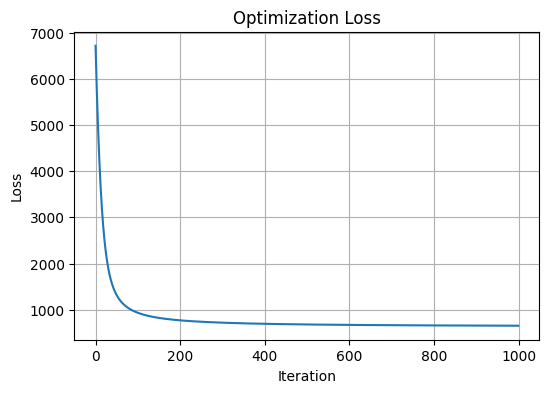

In [20]:

###############################################################
# Plots
###############################################################

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.grid()

plt.title("Optimization Loss")

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.show()


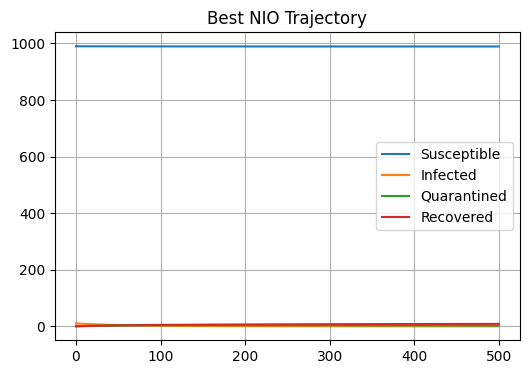

In [22]:

###############################################################

plt.figure(figsize=(6,4))

plt.plot(best_traj[:,0,0].detach().cpu(),label="Susceptible")

plt.plot(best_traj[:,0,1].detach().cpu(),label="Infected")

plt.plot(best_traj[:,0,2].detach().cpu(),label="Quarantined")

plt.plot(best_traj[:,0,3].detach().cpu(),label="Recovered")

plt.legend()

plt.grid()

plt.title("Best NIO Trajectory")

plt.show()


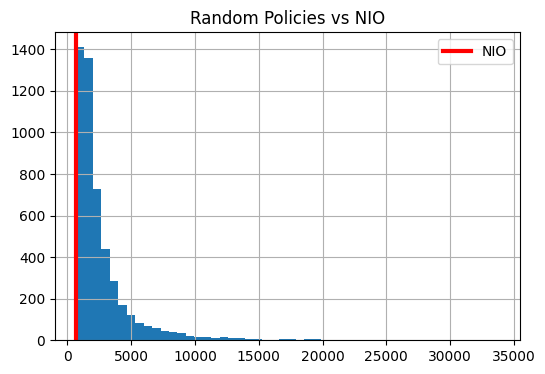

In [23]:

###############################################################

plt.figure(figsize=(6,4))

plt.hist(random_scores,bins=50)

plt.axvline(loss_history[-1],
            color='red',
            linewidth=3,
            label="NIO")

plt.legend()

plt.grid()

plt.title("Random Policies vs NIO")

plt.show()


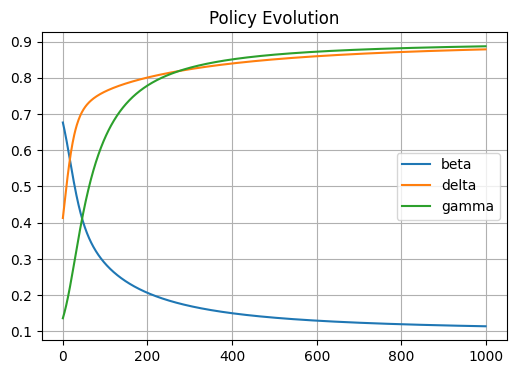

In [24]:

###############################################################

plt.figure(figsize=(6,4))

plt.plot(beta_history,label="beta")

plt.plot(delta_history,label="delta")

plt.plot(gamma_history,label="gamma")

plt.legend()

plt.grid()

plt.title("Policy Evolution")

plt.show()




## Version 2 - Minimize case


In [35]:


###############################################################
#
# cyber_nio.py
#
# Neural Input Optimization (NIO)
# for Cybersecurity Policy Discovery
#
###############################################################

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [36]:



torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"


In [37]:


###############################################################
# Simulation
###############################################################

dt = 0.05
Time_steps = 400
iters = 1000


In [38]:


###############################################################
# Enterprise Network
###############################################################

TOTAL_HOSTS = 1000.0


In [39]:


###############################################################
# Fixed Parameters
###############################################################

alpha = 0.30        # exposed -> infected
eta   = 0.15        # quarantine -> recovered


In [40]:


###############################################################
# Policy Bounds
###############################################################

beta_min  = 0.10
beta_max  = 0.90

delta_min = 0.05
delta_max = 0.90

gamma_min = 0.05
gamma_max = 0.90


In [42]:

###############################################################
# Initial Network
###############################################################

S0 = 985.0
E0 = 5.0
I0 = 10.0
Q0 = 0.0
R0 = 0.0


In [43]:



###############################################################
# Cyber Dynamical System
###############################################################

class CyberStep(nn.Module):

    def __init__(self,dt=0.05):
        super().__init__()
        self.dt = dt

    def forward(self,state,beta,delta,gamma):

        S = state[:,0]
        E = state[:,1]
        I = state[:,2]
        Q = state[:,3]
        R = state[:,4]

        #######################################################
        # SEIQR Equations
        #######################################################

        dS = -beta*S*I/TOTAL_HOSTS

        dE = beta*S*I/TOTAL_HOSTS \
             - alpha*E

        dI = alpha*E \
             - delta*I \
             - gamma*I

        dQ = delta*I \
             - eta*Q

        dR = gamma*I \
             + eta*Q

        #######################################################
        # Euler
        #######################################################

        S = S + self.dt*dS
        E = E + self.dt*dE
        I = I + self.dt*dI
        Q = Q + self.dt*dQ
        R = R + self.dt*dR

        #######################################################
        # Clamp
        #######################################################

        S = torch.clamp(S,min=0)
        E = torch.clamp(E,min=0)
        I = torch.clamp(I,min=0)
        Q = torch.clamp(Q,min=0)
        R = torch.clamp(R,min=0)

        return torch.stack([S,E,I,Q,R],dim=1)



In [44]:

model = CyberStep(dt).to(device)




In [45]:


###############################################################
# Simulation
###############################################################

def simulate(beta, delta, gamma):

    state = torch.tensor(
        [[S0, E0, I0, Q0, R0]],
        dtype=torch.float32,
        device=device
    )

    trajectory = [state.clone()]

    for k in range(Time_steps):

        state = model(state, beta, delta, gamma)

        trajectory.append(state.clone())

    trajectory = torch.stack(trajectory)

    return trajectory


In [46]:



###############################################################
# NIO variables
###############################################################

z = torch.randn(3, device=device, requires_grad=True)

optimizer = optim.Adam([z], lr=0.05)


In [47]:


###############################################################
# History
###############################################################

loss_history = []

beta_history = []
delta_history = []
gamma_history = []


In [48]:


###############################################################
# Optimization
###############################################################

print()
print("Running NIO Optimization")
print()

for iteration in range(iters):

    ###########################################################
    # Policy variables
    ###########################################################

    beta = beta_min + (beta_max-beta_min) * torch.sigmoid(z[0])

    delta = delta_min + (delta_max-delta_min) * torch.sigmoid(z[1])

    gamma = gamma_min + (gamma_max-gamma_min) * torch.sigmoid(z[2])

    ###########################################################
    # Simulate outbreak
    ###########################################################

    traj = simulate(beta, delta, gamma)

    ###########################################################
    # States
    ###########################################################

    S = traj[:,0,0]
    E = traj[:,0,1]
    I = traj[:,0,2]
    Q = traj[:,0,3]
    R = traj[:,0,4]

    ###########################################################
    # Objective
    #
    # Minimize total infected over the outbreak
    ###########################################################

    total_infected = torch.sum(I)

    loss = total_infected

    ###########################################################
    # Gradient step
    ###########################################################

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ###########################################################
    # Save history
    ###########################################################

    loss_history.append(loss.item())

    beta_history.append(beta.item())
    delta_history.append(delta.item())
    gamma_history.append(gamma.item())

    ###########################################################
    # Progress
    ###########################################################

    if iteration % 100 == 0:

        print(
            "Iter:",
            iteration,
            "Loss:",
            round(loss.item(),3),
            "beta:",
            round(beta.item(),3),
            "delta:",
            round(delta.item(),3),
            "gamma:",
            round(gamma.item(),3)
        )




Running NIO Optimization

Iter: 0 Loss: 4004.771 beta: 0.759 delta: 0.413 gamma: 0.136
Iter: 100 Loss: 342.001 beta: 0.361 delta: 0.716 gamma: 0.504
Iter: 200 Loss: 256.299 beta: 0.26 delta: 0.752 gamma: 0.668
Iter: 300 Loss: 227.004 beta: 0.212 delta: 0.775 gamma: 0.75
Iter: 400 Loss: 212.612 beta: 0.184 delta: 0.793 gamma: 0.795
Iter: 500 Loss: 204.106 beta: 0.165 delta: 0.808 gamma: 0.821
Iter: 600 Loss: 198.495 beta: 0.153 delta: 0.819 gamma: 0.839
Iter: 700 Loss: 194.523 beta: 0.143 delta: 0.829 gamma: 0.851
Iter: 800 Loss: 191.57 beta: 0.136 delta: 0.838 gamma: 0.859
Iter: 900 Loss: 189.296 beta: 0.131 delta: 0.845 gamma: 0.866


In [49]:


###############################################################
# Best policy
###############################################################

best_beta = beta.detach()

best_delta = delta.detach()

best_gamma = gamma.detach()

best_traj = simulate(best_beta, best_delta, best_gamma)

print()
print("Optimization Finished")
print()

print("Best Policy")

print("beta :", best_beta.item())
print("delta:", best_delta.item())
print("gamma:", best_gamma.item())



Optimization Finished

Best Policy
beta : 0.12677869200706482
delta: 0.8509111404418945
gamma: 0.8708588480949402


In [50]:


###############################################################
# Random Policy Search
###############################################################

print()
print("Running Random Search")
print()

Nrandom = 5000

random_scores = []

random_beta = []
random_delta = []
random_gamma = []

best_random_score = 1e30

best_random_beta = None
best_random_delta = None
best_random_gamma = None

for k in range(Nrandom):

    beta = beta_min + (beta_max-beta_min)*torch.rand(1,device=device)

    delta = delta_min + (delta_max-delta_min)*torch.rand(1,device=device)

    gamma = gamma_min + (gamma_max-gamma_min)*torch.rand(1,device=device)

    traj = simulate(beta,delta,gamma)

    I = traj[:,0,2]

    score = torch.sum(I)

    random_scores.append(score.item())

    random_beta.append(beta.item())
    random_delta.append(delta.item())
    random_gamma.append(gamma.item())

    if score.item() < best_random_score:

        best_random_score = score.item()

        best_random_beta = beta.item()
        best_random_delta = delta.item()
        best_random_gamma = gamma.item()




Running Random Search



In [51]:


###############################################################
# Print comparison
###############################################################

print()
print("---------------------------------------")
print("Random Search")
print("---------------------------------------")
print("Best Score :", best_random_score)
print("beta       :", best_random_beta)
print("delta      :", best_random_delta)
print("gamma      :", best_random_gamma)

print()

print("---------------------------------------")
print("NIO")
print("---------------------------------------")
print("Score :", loss_history[-1])
print("beta  :", best_beta.item())
print("delta :", best_delta.item())
print("gamma :", best_gamma.item())



---------------------------------------
Random Search
---------------------------------------
Best Score : 186.97048950195312
beta       : 0.16533619165420532
delta      : 0.8668149709701538
gamma      : 0.8969847559928894

---------------------------------------
NIO
---------------------------------------
Score : 187.51251220703125
beta  : 0.12677869200706482
delta : 0.8509111404418945
gamma : 0.8708588480949402


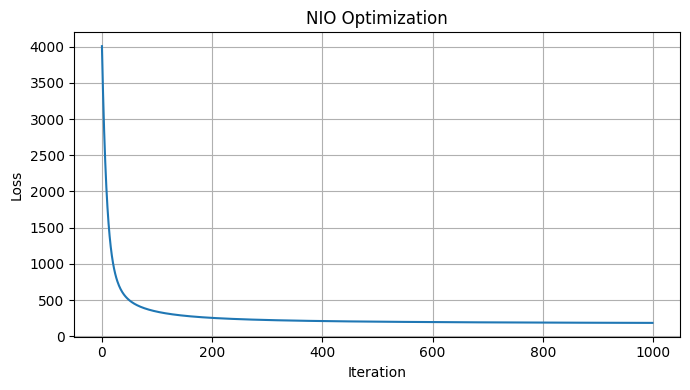

In [52]:

###############################################################
# Plot Optimization Loss
###############################################################

plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.grid(True)

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.title("NIO Optimization")

plt.tight_layout()

plt.show()


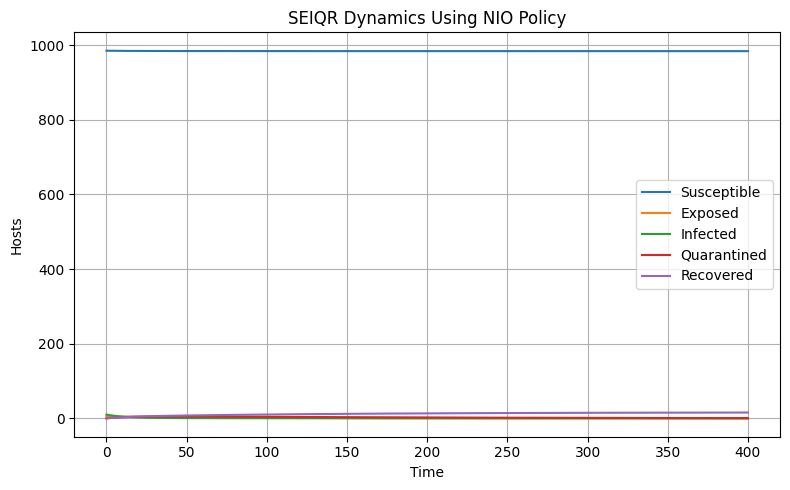

In [53]:


###############################################################
# Best Trajectory
###############################################################

S = best_traj[:,0,0].cpu().numpy()
E = best_traj[:,0,1].cpu().numpy()
I = best_traj[:,0,2].cpu().numpy()
Q = best_traj[:,0,3].cpu().numpy()
R = best_traj[:,0,4].cpu().numpy()

plt.figure(figsize=(8,5))

plt.plot(S,label="Susceptible")
plt.plot(E,label="Exposed")
plt.plot(I,label="Infected")
plt.plot(Q,label="Quarantined")
plt.plot(R,label="Recovered")

plt.grid(True)

plt.legend()

plt.xlabel("Time")

plt.ylabel("Hosts")

plt.title("SEIQR Dynamics Using NIO Policy")

plt.tight_layout()

plt.show()


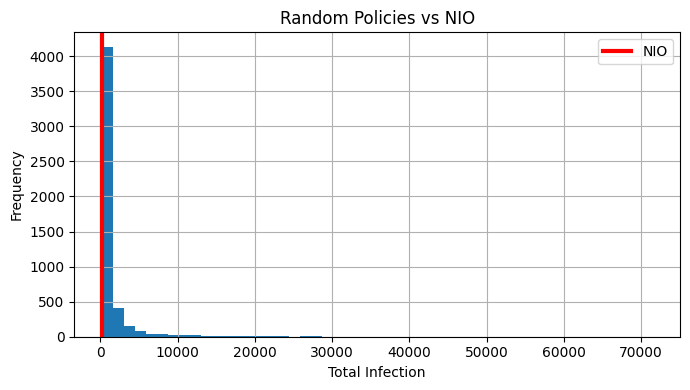

In [54]:

###############################################################
# Histogram
###############################################################

plt.figure(figsize=(7,4))

plt.hist(random_scores,
         bins=50)

plt.axvline(loss_history[-1],
            color='red',
            linewidth=3,
            label="NIO")

plt.legend()

plt.xlabel("Total Infection")

plt.ylabel("Frequency")

plt.title("Random Policies vs NIO")

plt.grid(True)

plt.tight_layout()

plt.show()


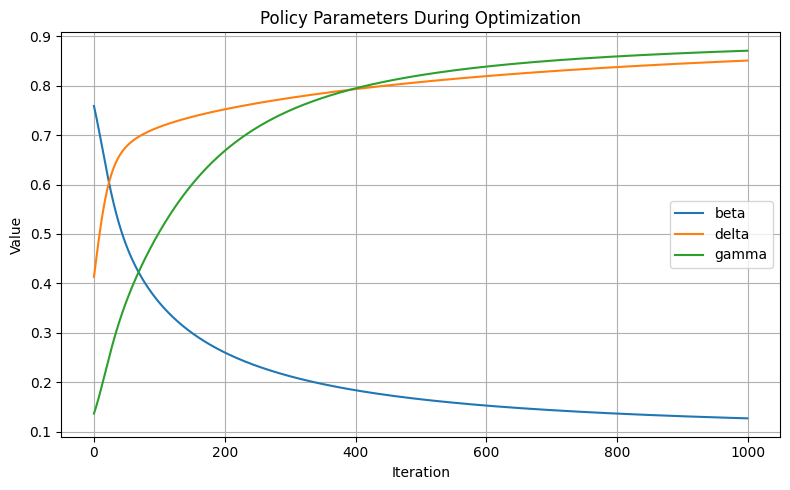

In [55]:

###############################################################
# Policy Evolution
###############################################################

plt.figure(figsize=(8,5))

plt.plot(beta_history,label="beta")

plt.plot(delta_history,label="delta")

plt.plot(gamma_history,label="gamma")

plt.legend()

plt.grid(True)

plt.xlabel("Iteration")

plt.ylabel("Value")

plt.title("Policy Parameters During Optimization")

plt.tight_layout()

plt.show()


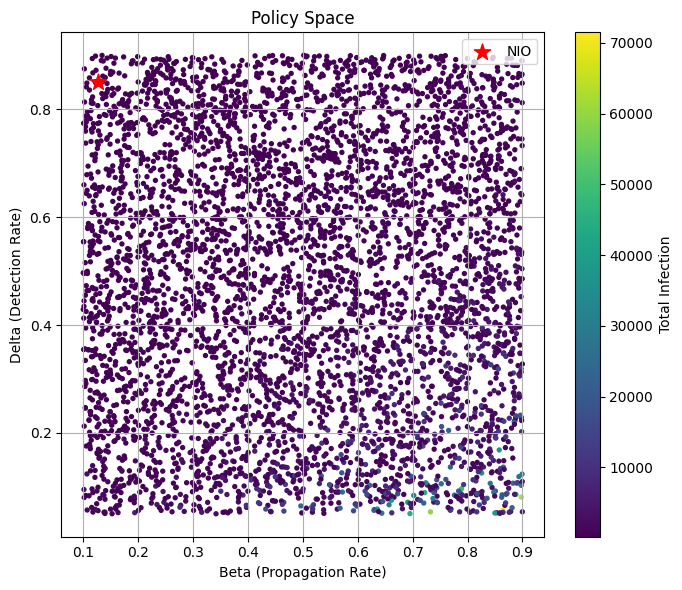

In [56]:

###############################################################
# Scatter Plot of Policy Space
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_beta,
                 random_delta,
                 c=random_scores,
                 s=8,
                 cmap="viridis")

plt.scatter(best_beta.cpu().item(),
            best_delta.cpu().item(),
            color="red",
            s=150,
            marker="*",
            label="NIO")

plt.xlabel("Beta (Propagation Rate)")

plt.ylabel("Delta (Detection Rate)")

plt.title("Policy Space")

plt.legend()

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


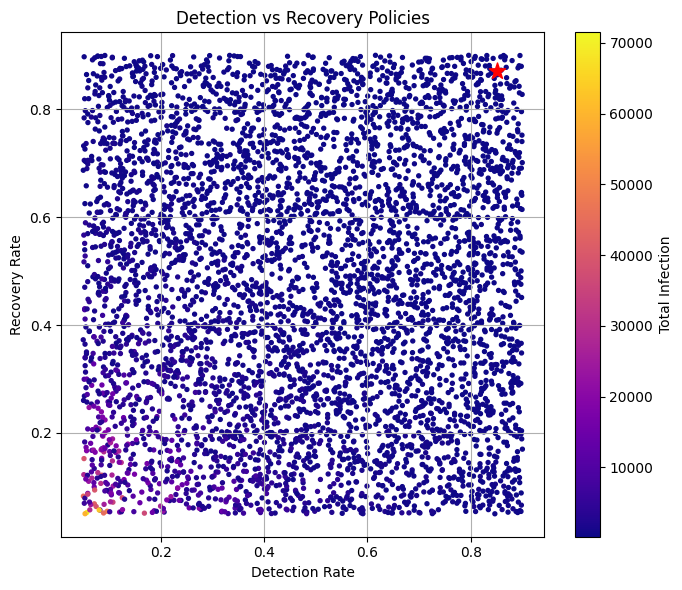

In [57]:

###############################################################
# Delta vs Gamma
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_delta,
                 random_gamma,
                 c=random_scores,
                 s=8,
                 cmap="plasma")

plt.scatter(best_delta.cpu().item(),
            best_gamma.cpu().item(),
            color="red",
            marker="*",
            s=150)

plt.xlabel("Detection Rate")

plt.ylabel("Recovery Rate")

plt.title("Detection vs Recovery Policies")

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


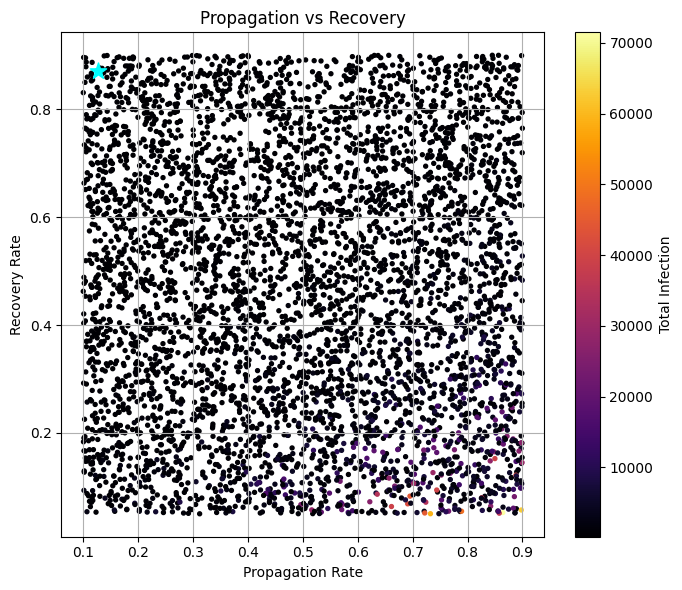

In [58]:

###############################################################
# Beta vs Gamma
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_beta,
                 random_gamma,
                 c=random_scores,
                 s=8,
                 cmap="inferno")

plt.scatter(best_beta.cpu().item(),
            best_gamma.cpu().item(),
            color="cyan",
            marker="*",
            s=150)

plt.xlabel("Propagation Rate")

plt.ylabel("Recovery Rate")

plt.title("Propagation vs Recovery")

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


In [59]:


###############################################################
# Statistics
###############################################################

import numpy as np

random_scores = np.array(random_scores)

print()

print("================================================")

print("Random Search Statistics")

print("================================================")

print("Mean :", np.mean(random_scores))

print("Std  :", np.std(random_scores))

print("Min  :", np.min(random_scores))

print("Max  :", np.max(random_scores))

print()

print("================================================")

print("NIO")

print("================================================")

print("Score :", loss_history[-1])

print("Improvement over Random Mean (%)")

improvement = 100.0 * (
    np.mean(random_scores) - loss_history[-1]
) / np.mean(random_scores)

print(improvement)




Random Search Statistics
Mean : 1549.3971912628174
Std  : 3766.1801584243885
Min  : 186.97048950195312
Max  : 71472.21875

NIO
Score : 187.51251220703125
Improvement over Random Mean (%)
87.89771188017957


In [60]:


###############################################################
# Save Best Trajectory
###############################################################

torch.save(best_traj.cpu(),"best_trajectory.pt")

print()

print("Trajectory saved.")



Trajectory saved.


In [62]:


###############################################################
#
# Multiple NIO Experiments
#
###############################################################

Nruns = 10  ### 100

nio_scores = []

nio_beta = []
nio_delta = []
nio_gamma = []

print()
print("==========================================")
print("Running Multiple NIO Experiments")
print("==========================================")
print()

for run in range(Nruns):

    ###########################################################
    # New optimization variables
    ###########################################################

    z = torch.randn(3,device=device,requires_grad=True)

    optimizer = optim.Adam([z],lr=0.05)

    ###########################################################

    for iteration in range(iters):

        beta = beta_min + (beta_max-beta_min) * torch.sigmoid(z[0])

        delta = delta_min + (delta_max-delta_min) * torch.sigmoid(z[1])

        gamma = gamma_min + (gamma_max-gamma_min) * torch.sigmoid(z[2])

        traj = simulate(beta,delta,gamma)

        I = traj[:,0,2]

        loss = torch.sum(I)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    ###########################################################

    nio_scores.append(loss.item())

    nio_beta.append(beta.item())

    nio_delta.append(delta.item())

    nio_gamma.append(gamma.item())

    if run%1==0:

        print(run,loss.item())






Running Multiple NIO Experiments

0 177.7149658203125
1 179.17974853515625
2 176.7989959716797
3 176.42596435546875
4 176.7028350830078
5 176.738525390625
6 177.05345153808594
7 177.53652954101562
8 176.72076416015625
9 176.4107208251953


In [63]:


###############################################################
#
# Statistics
#
###############################################################

import numpy as np

nio_scores = np.array(nio_scores)

random_scores = np.array(random_scores)

print()

print("===================================")

print("NIO")

print("===================================")

print("Mean :",np.mean(nio_scores))

print("Std  :",np.std(nio_scores))

print("Min  :",np.min(nio_scores))

print("Max  :",np.max(nio_scores))

print()

print("===================================")

print("Random")

print("===================================")

print("Mean :",np.mean(random_scores))

print("Std  :",np.std(random_scores))

print("Min  :",np.min(random_scores))

print("Max  :",np.max(random_scores))





NIO
Mean : 177.1282501220703
Std  : 0.7962749511237028
Min  : 176.4107208251953
Max  : 179.17974853515625

Random
Mean : 1549.3971912628174
Std  : 3766.1801584243885
Min  : 186.97048950195312
Max  : 71472.21875


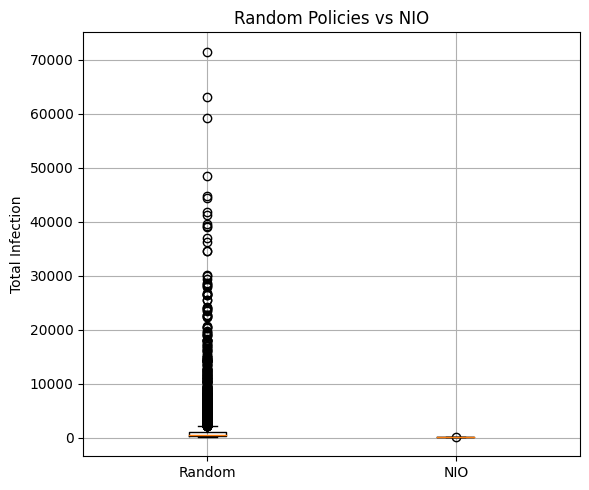

In [64]:



###############################################################
#
# Boxplot
#
###############################################################

plt.figure(figsize=(6,5))

plt.boxplot(
    [random_scores,nio_scores],
    labels=["Random","NIO"]
)

plt.ylabel("Total Infection")

plt.title("Random Policies vs NIO")

plt.grid(True)

plt.tight_layout()

plt.show()


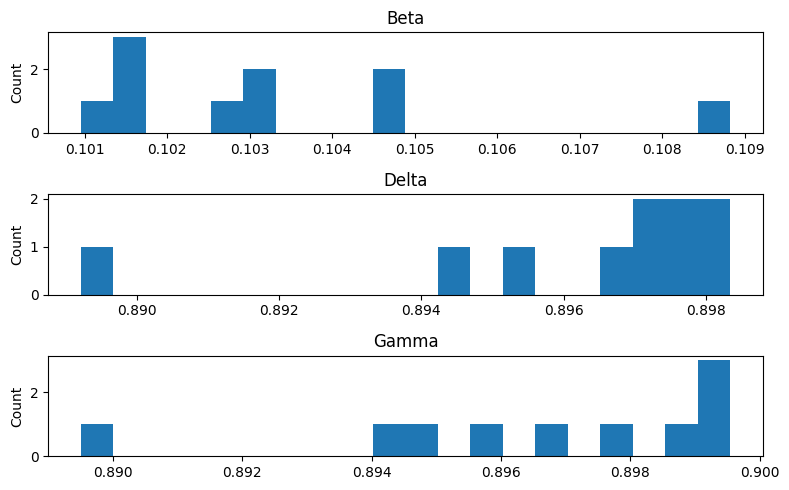

In [65]:



###############################################################
#
# Learned Policies
#
###############################################################

plt.figure(figsize=(8,5))

plt.subplot(311)

plt.hist(nio_beta,bins=20)

plt.ylabel("Count")

plt.title("Beta")

plt.subplot(312)

plt.hist(nio_delta,bins=20)

plt.ylabel("Count")

plt.title("Delta")

plt.subplot(313)

plt.hist(nio_gamma,bins=20)

plt.ylabel("Count")

plt.title("Gamma")

plt.tight_layout()

plt.show()




In [66]:



###############################################################
#
# Save Results
#
###############################################################

results = {

    "nio_scores":nio_scores,

    "random_scores":random_scores,

    "beta":nio_beta,

    "delta":nio_delta,

    "gamma":nio_gamma

}

torch.save(results,"cyber_results.pt")

print()

print("Finished.")

print("Results saved.")





Finished.
Results saved.



## Version 2 - Maximization case


In [67]:



###############################################################
#
# cyber_nio.py
#
# Neural Input Optimization (NIO)
# for Cybersecurity Policy Discovery
#
###############################################################

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [68]:

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"



In [69]:

###############################################################
# Simulation
###############################################################

dt = 0.05
Time_steps = 400
iters = 1000


In [70]:

###############################################################
# Enterprise Network
###############################################################

TOTAL_HOSTS = 1000.0



In [71]:



###############################################################
# Fixed Parameters
###############################################################

alpha = 0.30        # exposed -> infected
eta   = 0.15        # quarantine -> recovered



In [72]:


###############################################################
# Policy Bounds
###############################################################

beta_min  = 0.10
beta_max  = 0.90

delta_min = 0.05
delta_max = 0.90

gamma_min = 0.05
gamma_max = 0.90


In [73]:



###############################################################
# Initial Network
###############################################################

S0 = 985.0
E0 = 5.0
I0 = 10.0
Q0 = 0.0
R0 = 0.0


In [74]:



###############################################################
# Cyber Dynamical System
###############################################################

class CyberStep(nn.Module):

    def __init__(self,dt=0.05):
        super().__init__()
        self.dt = dt

    def forward(self,state,beta,delta,gamma):

        S = state[:,0]
        E = state[:,1]
        I = state[:,2]
        Q = state[:,3]
        R = state[:,4]

        #######################################################
        # SEIQR Equations
        #######################################################

        dS = -beta*S*I/TOTAL_HOSTS

        dE = beta*S*I/TOTAL_HOSTS \
             - alpha*E

        dI = alpha*E \
             - delta*I \
             - gamma*I

        dQ = delta*I \
             - eta*Q

        dR = gamma*I \
             + eta*Q

        #######################################################
        # Euler
        #######################################################

        S = S + self.dt*dS
        E = E + self.dt*dE
        I = I + self.dt*dI
        Q = Q + self.dt*dQ
        R = R + self.dt*dR

        #######################################################
        # Clamp
        #######################################################

        S = torch.clamp(S,min=0)
        E = torch.clamp(E,min=0)
        I = torch.clamp(I,min=0)
        Q = torch.clamp(Q,min=0)
        R = torch.clamp(R,min=0)

        return torch.stack([S,E,I,Q,R],dim=1)




In [75]:


model = CyberStep(dt).to(device)



In [76]:


###############################################################
# Simulation
###############################################################

def simulate(beta, delta, gamma):

    state = torch.tensor(
        [[S0, E0, I0, Q0, R0]],
        dtype=torch.float32,
        device=device
    )

    trajectory = [state.clone()]

    for k in range(Time_steps):

        state = model(state, beta, delta, gamma)

        trajectory.append(state.clone())

    trajectory = torch.stack(trajectory)

    return trajectory




In [77]:


###############################################################
# NIO variables
###############################################################

z = torch.randn(3, device=device, requires_grad=True)

optimizer = optim.Adam([z], lr=0.05)



In [78]:


###############################################################
# History
###############################################################

loss_history = []

beta_history = []
delta_history = []
gamma_history = []



In [79]:




###############################################################
# Optimization
###############################################################

print()
print("Running NIO Optimization")
print()

for iteration in range(iters):

    ###########################################################
    # Policy variables
    ###########################################################

    beta = beta_min + (beta_max-beta_min) * torch.sigmoid(z[0])

    delta = delta_min + (delta_max-delta_min) * torch.sigmoid(z[1])

    gamma = gamma_min + (gamma_max-gamma_min) * torch.sigmoid(z[2])

    ###########################################################
    # Simulate outbreak
    ###########################################################

    traj = simulate(beta, delta, gamma)

    ###########################################################
    # States
    ###########################################################

    S = traj[:,0,0]
    E = traj[:,0,1]
    I = traj[:,0,2]
    Q = traj[:,0,3]
    R = traj[:,0,4]

    ###########################################################
    # Objective
    #
    # When positive you Minimize total infected over the outbreak
    ###########################################################
    
    ## When negative Now NIO searches for policies that produce the largest outbreak.
    ## loss = -torch.sum(I)

    total_infected = -torch.sum(I)

    loss = total_infected

    ###########################################################
    # Gradient step
    ###########################################################

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ###########################################################
    # Save history
    ###########################################################

    loss_history.append(loss.item())

    beta_history.append(beta.item())
    delta_history.append(delta.item())
    gamma_history.append(gamma.item())

    ###########################################################
    # Progress
    ###########################################################

    if iteration % 100 == 0:

        print(
            "Iter:",
            iteration,
            "Loss:",
            round(loss.item(),3),
            "beta:",
            round(beta.item(),3),
            "delta:",
            round(delta.item(),3),
            "gamma:",
            round(gamma.item(),3)
        )



Running NIO Optimization

Iter: 0 Loss: -4004.771 beta: 0.759 delta: 0.413 gamma: 0.136
Iter: 100 Loss: -74412.82 beta: 0.896 delta: 0.058 gamma: 0.052
Iter: 200 Loss: -77600.812 beta: 0.898 delta: 0.053 gamma: 0.051
Iter: 300 Loss: -78339.062 beta: 0.899 delta: 0.051 gamma: 0.05
Iter: 400 Loss: -78648.312 beta: 0.899 delta: 0.051 gamma: 0.05
Iter: 500 Loss: -78811.93 beta: 0.9 delta: 0.051 gamma: 0.05
Iter: 600 Loss: -78910.703 beta: 0.9 delta: 0.05 gamma: 0.05
Iter: 700 Loss: -78975.516 beta: 0.9 delta: 0.05 gamma: 0.05
Iter: 800 Loss: -79020.75 beta: 0.9 delta: 0.05 gamma: 0.05
Iter: 900 Loss: -79053.781 beta: 0.9 delta: 0.05 gamma: 0.05


In [80]:


###############################################################
# Best policy
###############################################################

best_beta = beta.detach()

best_delta = delta.detach()

best_gamma = gamma.detach()

best_traj = simulate(best_beta, best_delta, best_gamma)

print()
print("Optimization Finished")
print()

print("Best Policy")

print("beta :", best_beta.item())
print("delta:", best_delta.item())
print("gamma:", best_gamma.item())



Optimization Finished

Best Policy
beta : 0.8998635411262512
delta: 0.05020906403660774
gamma: 0.05004322528839111


In [81]:


###############################################################
# Random Policy Search
###############################################################

print()
print("Running Random Search")
print()

Nrandom = 5000

random_scores = []

random_beta = []
random_delta = []
random_gamma = []

best_random_score = 1e30

best_random_beta = None
best_random_delta = None
best_random_gamma = None

for k in range(Nrandom):

    beta = beta_min + (beta_max-beta_min)*torch.rand(1,device=device)

    delta = delta_min + (delta_max-delta_min)*torch.rand(1,device=device)

    gamma = gamma_min + (gamma_max-gamma_min)*torch.rand(1,device=device)

    traj = simulate(beta,delta,gamma)

    I = traj[:,0,2]

    score = torch.sum(I)

    random_scores.append(score.item())

    random_beta.append(beta.item())
    random_delta.append(delta.item())
    random_gamma.append(gamma.item())

    if score.item() < best_random_score:

        best_random_score = score.item()

        best_random_beta = beta.item()
        best_random_delta = delta.item()
        best_random_gamma = gamma.item()




Running Random Search



In [82]:

###############################################################
# Print comparison
###############################################################

print()
print("---------------------------------------")
print("Random Search")
print("---------------------------------------")
print("Best Score :", best_random_score)
print("beta       :", best_random_beta)
print("delta      :", best_random_delta)
print("gamma      :", best_random_gamma)

print()

print("---------------------------------------")
print("NIO")
print("---------------------------------------")
print("Score :", loss_history[-1])
print("beta  :", best_beta.item())
print("delta :", best_delta.item())
print("gamma :", best_gamma.item())



---------------------------------------
Random Search
---------------------------------------
Best Score : 186.97048950195312
beta       : 0.16533619165420532
delta      : 0.8668149709701538
gamma      : 0.8969847559928894

---------------------------------------
NIO
---------------------------------------
Score : -79078.5
beta  : 0.8998635411262512
delta : 0.05020906403660774
gamma : 0.05004322528839111


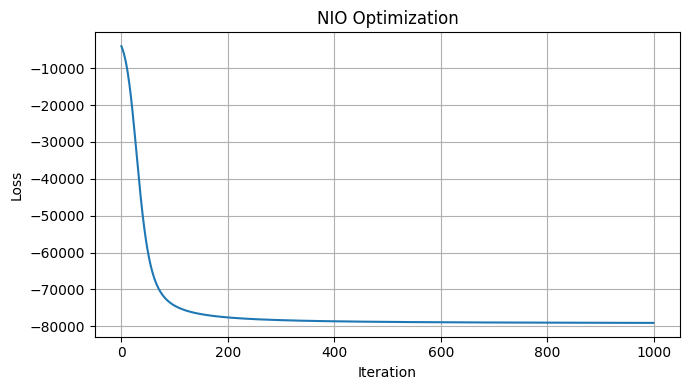

In [83]:


###############################################################
# Plot Optimization Loss
###############################################################

plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.grid(True)

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.title("NIO Optimization")

plt.tight_layout()

plt.show()


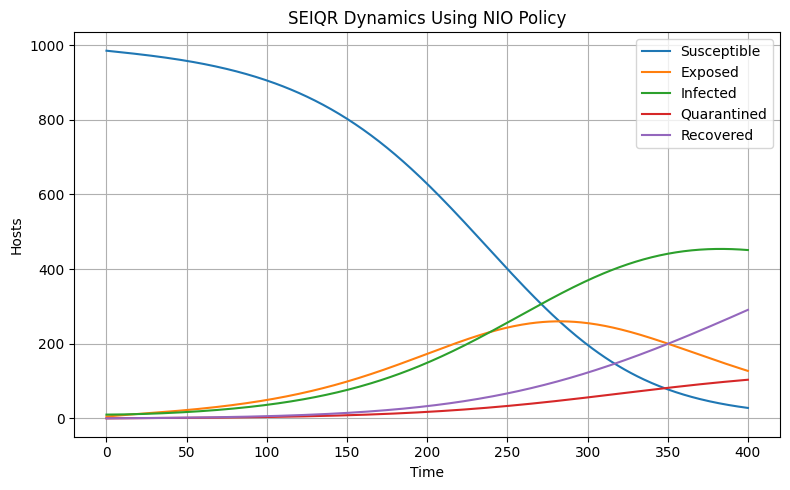

In [84]:

###############################################################
# Best Trajectory
###############################################################

S = best_traj[:,0,0].cpu().numpy()
E = best_traj[:,0,1].cpu().numpy()
I = best_traj[:,0,2].cpu().numpy()
Q = best_traj[:,0,3].cpu().numpy()
R = best_traj[:,0,4].cpu().numpy()

plt.figure(figsize=(8,5))

plt.plot(S,label="Susceptible")
plt.plot(E,label="Exposed")
plt.plot(I,label="Infected")
plt.plot(Q,label="Quarantined")
plt.plot(R,label="Recovered")

plt.grid(True)

plt.legend()

plt.xlabel("Time")

plt.ylabel("Hosts")

plt.title("SEIQR Dynamics Using NIO Policy")

plt.tight_layout()

plt.show()



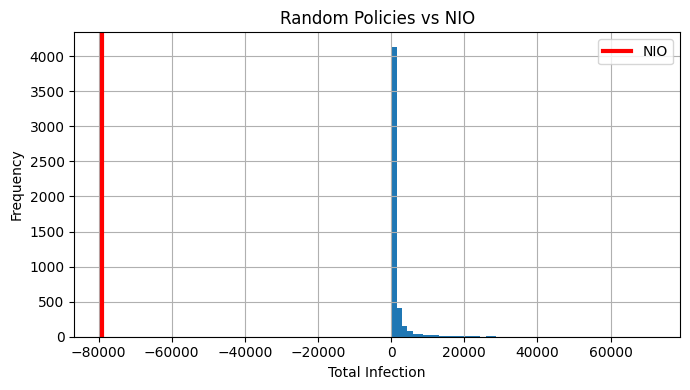

In [85]:



###############################################################
# Histogram
###############################################################

plt.figure(figsize=(7,4))

plt.hist(random_scores,
         bins=50)

plt.axvline(loss_history[-1],
            color='red',
            linewidth=3,
            label="NIO")

plt.legend()

plt.xlabel("Total Infection")

plt.ylabel("Frequency")

plt.title("Random Policies vs NIO")

plt.grid(True)

plt.tight_layout()

plt.show()


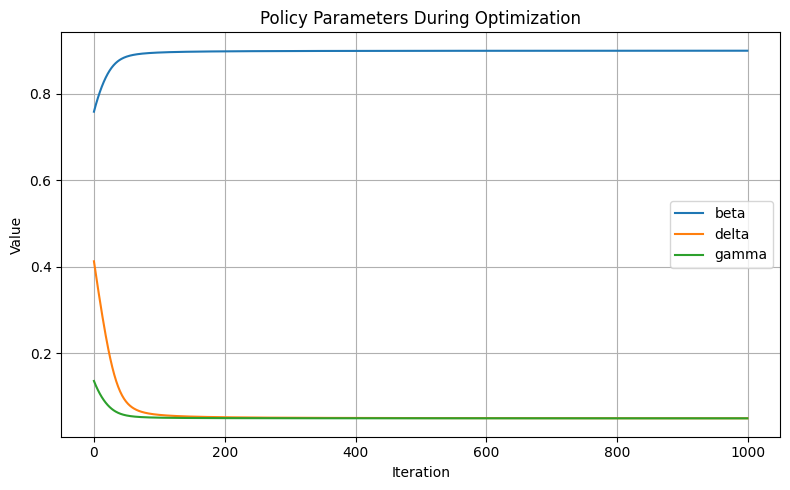

In [86]:



###############################################################
# Policy Evolution
###############################################################

plt.figure(figsize=(8,5))

plt.plot(beta_history,label="beta")

plt.plot(delta_history,label="delta")

plt.plot(gamma_history,label="gamma")

plt.legend()

plt.grid(True)

plt.xlabel("Iteration")

plt.ylabel("Value")

plt.title("Policy Parameters During Optimization")

plt.tight_layout()

plt.show()



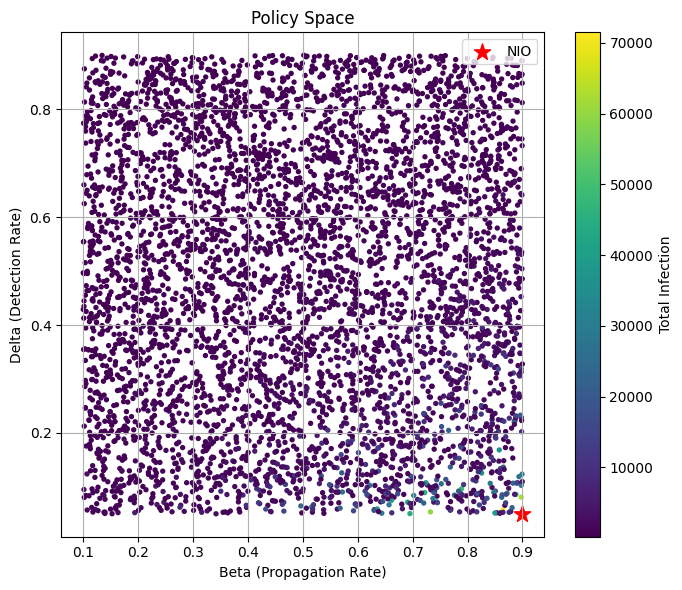

In [87]:

###############################################################
# Scatter Plot of Policy Space
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_beta,
                 random_delta,
                 c=random_scores,
                 s=8,
                 cmap="viridis")

plt.scatter(best_beta.cpu().item(),
            best_delta.cpu().item(),
            color="red",
            s=150,
            marker="*",
            label="NIO")

plt.xlabel("Beta (Propagation Rate)")

plt.ylabel("Delta (Detection Rate)")

plt.title("Policy Space")

plt.legend()

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


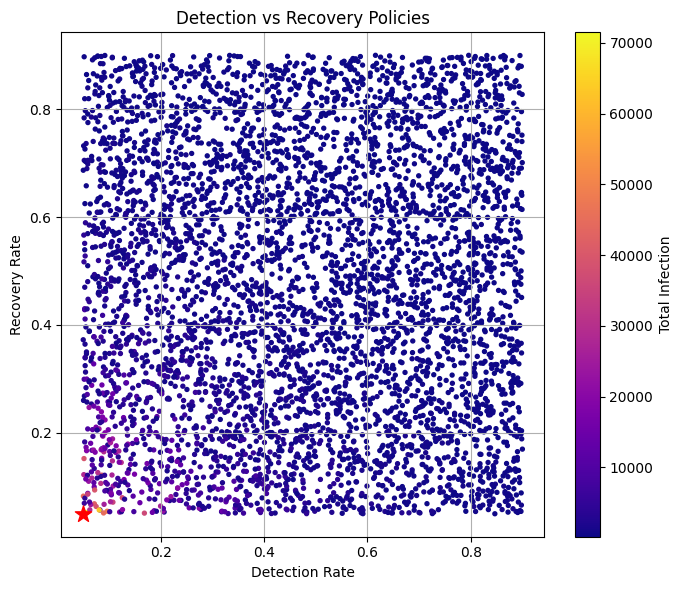

In [88]:


###############################################################
# Delta vs Gamma
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_delta,
                 random_gamma,
                 c=random_scores,
                 s=8,
                 cmap="plasma")

plt.scatter(best_delta.cpu().item(),
            best_gamma.cpu().item(),
            color="red",
            marker="*",
            s=150)

plt.xlabel("Detection Rate")

plt.ylabel("Recovery Rate")

plt.title("Detection vs Recovery Policies")

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


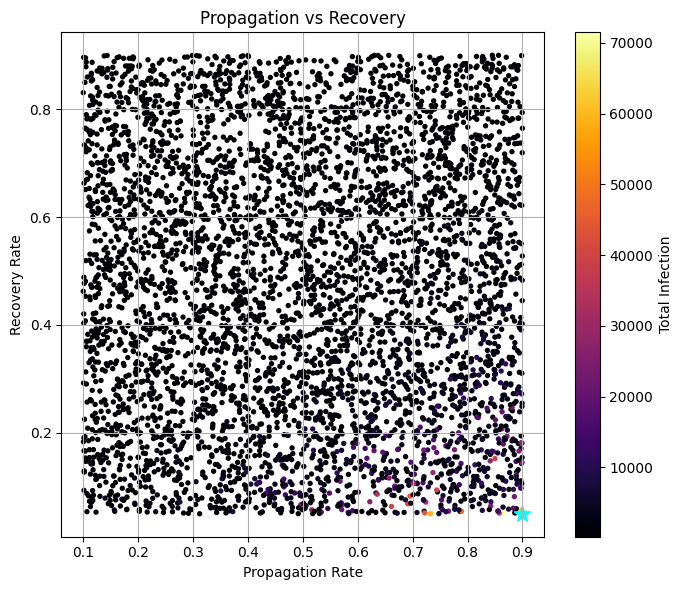

In [89]:


###############################################################
# Beta vs Gamma
###############################################################

plt.figure(figsize=(7,6))

sc = plt.scatter(random_beta,
                 random_gamma,
                 c=random_scores,
                 s=8,
                 cmap="inferno")

plt.scatter(best_beta.cpu().item(),
            best_gamma.cpu().item(),
            color="cyan",
            marker="*",
            s=150)

plt.xlabel("Propagation Rate")

plt.ylabel("Recovery Rate")

plt.title("Propagation vs Recovery")

plt.colorbar(sc,label="Total Infection")

plt.grid(True)

plt.tight_layout()

plt.show()


In [90]:



###############################################################
# Statistics
###############################################################

import numpy as np

random_scores = np.array(random_scores)

print()

print("================================================")

print("Random Search Statistics")

print("================================================")

print("Mean :", np.mean(random_scores))

print("Std  :", np.std(random_scores))

print("Min  :", np.min(random_scores))

print("Max  :", np.max(random_scores))

print()

print("================================================")

print("NIO")

print("================================================")

print("Score :", loss_history[-1])

print("Improvement over Random Mean (%)")

improvement = 100.0 * (
    np.mean(random_scores) - loss_history[-1]
) / np.mean(random_scores)

print(improvement)




Random Search Statistics
Mean : 1549.3971912628174
Std  : 3766.1801584243885
Min  : 186.97048950195312
Max  : 71472.21875

NIO
Score : -79078.5
Improvement over Random Mean (%)
5203.823631921524


In [91]:



###############################################################
# Save Best Trajectory
###############################################################

torch.save(best_traj.cpu(),"best_trajectory.pt")

print()

print("Trajectory saved.")



Trajectory saved.


In [93]:




###############################################################
#
# Multiple NIO Experiments
#
###############################################################

Nruns = 4

nio_scores = []

nio_beta = []
nio_delta = []
nio_gamma = []

print()
print("==========================================")
print("Running Multiple NIO Experiments")
print("==========================================")
print()

for run in range(Nruns):

    ###########################################################
    # New optimization variables
    ###########################################################

    z = torch.randn(3,device=device,requires_grad=True)

    optimizer = optim.Adam([z],lr=0.05)

    ###########################################################

    for iteration in range(iters):

        beta = beta_min + (beta_max-beta_min) * torch.sigmoid(z[0])

        delta = delta_min + (delta_max-delta_min) * torch.sigmoid(z[1])

        gamma = gamma_min + (gamma_max-gamma_min) * torch.sigmoid(z[2])

        traj = simulate(beta,delta,gamma)

        I = traj[:,0,2]

        loss = -torch.sum(I)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    ###########################################################

    nio_scores.append(loss.item())

    nio_beta.append(beta.item())

    nio_delta.append(delta.item())

    nio_gamma.append(gamma.item())

    if run%1==0:

        print(run,loss.item())






Running Multiple NIO Experiments

0 -79081.1328125
1 -79087.8515625
2 -79095.3984375
3 -79088.171875


In [94]:


###############################################################
#
# Statistics
#
###############################################################

import numpy as np

nio_scores = np.array(nio_scores)

random_scores = np.array(random_scores)

print()

print("===================================")

print("NIO")

print("===================================")

print("Mean :",np.mean(nio_scores))

print("Std  :",np.std(nio_scores))

print("Min  :",np.min(nio_scores))

print("Max  :",np.max(nio_scores))

print()

print("===================================")

print("Random")

print("===================================")

print("Mean :",np.mean(random_scores))

print("Std  :",np.std(random_scores))

print("Min  :",np.min(random_scores))

print("Max  :",np.max(random_scores))





NIO
Mean : -79088.138671875
Std  : 5.046528429349469
Min  : -79095.3984375
Max  : -79081.1328125

Random
Mean : 1549.3971912628174
Std  : 3766.1801584243885
Min  : 186.97048950195312
Max  : 71472.21875


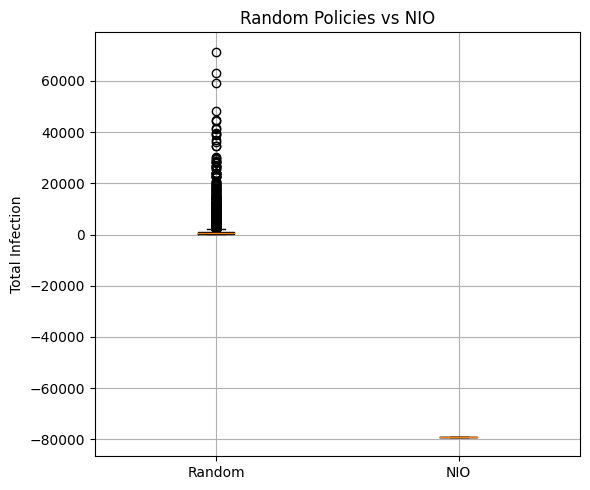

In [95]:


###############################################################
#
# Boxplot
#
###############################################################

plt.figure(figsize=(6,5))

plt.boxplot(
    [random_scores,nio_scores],
    labels=["Random","NIO"]
)

plt.ylabel("Total Infection")

plt.title("Random Policies vs NIO")

plt.grid(True)

plt.tight_layout()

plt.show()



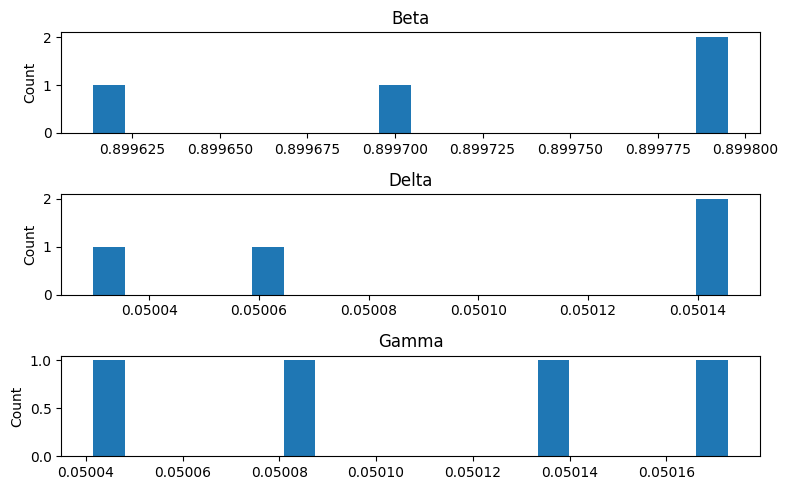

In [96]:


###############################################################
#
# Learned Policies
#
###############################################################

plt.figure(figsize=(8,5))

plt.subplot(311)

plt.hist(nio_beta,bins=20)

plt.ylabel("Count")

plt.title("Beta")

plt.subplot(312)

plt.hist(nio_delta,bins=20)

plt.ylabel("Count")

plt.title("Delta")

plt.subplot(313)

plt.hist(nio_gamma,bins=20)

plt.ylabel("Count")

plt.title("Gamma")

plt.tight_layout()

plt.show()




In [97]:



###############################################################
#
# Save Results
#
###############################################################

results = {

    "nio_scores":nio_scores,

    "random_scores":random_scores,

    "beta":nio_beta,

    "delta":nio_delta,

    "gamma":nio_gamma

}

torch.save(results,"cyber_results.pt")

print()

print("Finished.")

print("Results saved.")




Finished.
Results saved.



## Attacker vs. Defender


In [98]:



def run_nio(maximize=False):

    z = torch.randn(3, device=device, requires_grad=True)

    optimizer = optim.Adam([z], lr=0.05)

    loss_history = []

    for iteration in range(iters):

        beta = beta_min + (beta_max-beta_min) * torch.sigmoid(z[0])

        delta = delta_min + (delta_max-delta_min) * torch.sigmoid(z[1])

        gamma = gamma_min + (gamma_max-gamma_min) * torch.sigmoid(z[2])

        traj = simulate(beta, delta, gamma)

        I = traj[:,0,2]

        objective = torch.sum(I)

        if maximize:
            loss = -objective
        else:
            loss = objective

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return (
        beta.detach(),
        delta.detach(),
        gamma.detach(),
        traj.detach(),
        loss_history
    )





In [99]:


#######################################################
# Defender
#######################################################

beta_min_case, delta_min_case, gamma_min_case, traj_min, loss_min = run_nio(False)


In [100]:

#######################################################
# Attacker
#######################################################

beta_max_case, delta_max_case, gamma_max_case, traj_max, loss_max = run_nio(True)

